### loading datasets from kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sandipacharya10","key":"99993ff3d69b6554c9859c35b9db7cf9"}'}

In [ ]:
!mkdir -p ~/.kaggle/
!mv kaggle(1).json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle(1).json


/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `mv kaggle(1).json ~/.kaggle/'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `chmod 600 ~/.kaggle/kaggle(1).json'


In [ ]:
!kaggle datasets download -d inspiring-lab/nepali-number-plate-characters-dataset

Dataset URL: https://www.kaggle.com/datasets/inspiring-lab/nepali-number-plate-characters-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
nepali-number-plate-characters-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip <nepali-number-plate-characters-dataset.zip> -d /content/nepali-number-plate-characters-dataset


In [3]:
import numpy as np
import os
from skimage.feature import hog
import joblib
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd

In [ ]:
train_dir = 'character_ocr/'
labels_list = [i for i in os.listdir(train_dir)]
pathimg = [os.listdir(train_dir + i) for i in labels_list]

(32, 32)


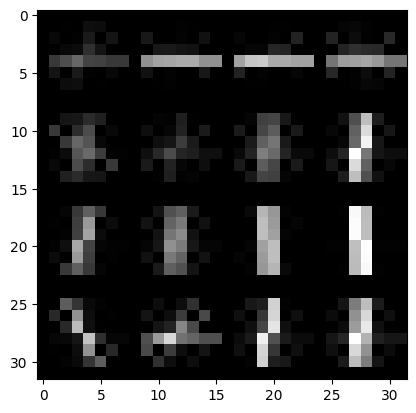

In [ ]:

# Visualize HOG for letter 'ना'
im_test =  cv2.imread('character_ocr/ना/ना_0.jpg',0)
print(im_test.shape)
_,hog_img= hog(im_test,orientations=9,pixels_per_cell=(8,8), cells_per_block=(1, 1),visualize=True)
plt.imshow(hog_img,cmap='gray')
# cv2.imwrite('AHog.jpg',hog_img)


In [ ]:
# extract the hog for each image and store it in a list with its 
# corresponding label
features = []
labels = []
for i,j in enumerate(zip(pathimg,labels_list)):
  imgs,label = j
  for img in imgs:
      img = cv2.imread(train_dir+label+'/'+img)
      img_res=cv2.resize(img,(64,128),interpolation=cv2.INTER_AREA)
      img_gray= cv2.cvtColor(img_res,cv2.COLOR_BGR2GRAY)
      hog_img= hog(img_gray,orientations=9,pixels_per_cell=(8,8), cells_per_block=(1, 1))
      features.append(hog_img)
      labels.append(label)

In [ ]:
print(len(pd.DataFrame(np.array(features))))
print(len(pd.DataFrame(np.array(labels))))

26537
26537


In [ ]:
df = pd.DataFrame(np.array(features))
df['target'] = labels
df

,0,1,2,3,4,5,6,7,8,9,...,1143,1144,1145,1146,1147,1148,1149,1150,1151,target
0,0.771818,0.197676,0.205101,0.000000,0.015187,0.299405,0.000000,0.246387,0.415422,0.747462,...,0.532555,0.128566,0.313658,0.532555,0.532555,0.048145,0.145641,0.103513,0.000000,भे
1,0.648920,0.347475,0.030417,0.048094,0.086033,0.048094,0.091252,0.125644,0.648920,0.674389,...,0.677466,0.377505,0.000000,0.000000,0.151322,0.000000,0.182494,0.294079,0.505811,भे
2,0.474852,0.000000,0.000000,0.276675,0.474852,0.452265,0.436476,0.188798,0.204406,0.535533,...,0.594282,0.160968,0.000000,0.278143,0.594282,0.402548,0.076883,0.098405,0.112890,भे
3,0.792175,0.490220,0.023370,0.068136,0.099152,0.036952,0.023370,0.147808,0.305556,0.550541,...,0.494171,0.208757,0.249971,0.494171,0.494171,0.312084,0.252154,0.018469,0.000000,भे
4,0.683861,0.396203,0.174614,0.088438,0.247369,0.000000,0.223694,0.148837,0.451290,0.600669,...,0.450202,0.240766,0.000000,0.250972,0.450202,0.450202,0.273766,0.035036,0.441387,भे
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26532,0.512137,0.108570,0.000000,0.512137,0.309136,0.512137,0.290866,0.145575,0.000000,0.565153,...,0.523893,0.290078,0.523893,0.334225,0.150324,0.080381,0.390995,0.249291,0.105545,८
26533,0.610749,0.147693,0.115860,0.091595,0.491550,0.274785,0.000000,0.515975,0.000000,0.503327,...,0.508505,0.508505,0.485057,0.056250,0.176090,0.056250,0.410383,0.090700,0.183269,८
26534,0.861248,0.105103,0.145752,0.130365,0.116602,0.130365,0.270003,0.170285,0.276545,0.515459,...,0.519193,0.188151,0.000000,0.514634,0.108138,0.467171,0.358384,0.194949,0.183855,८
26535,0.480475,0.125656,0.197710,0.480475,0.480475,0.480475,0.000000,0.000000,0.147300,0.488731,...,0.452074,0.000000,0.325760,0.452074,0.452074,0.276401,0.452074,0.000000,0.000000,८


In [ ]:
df['target'].unique()

array(['भे', 'ज', 'त', 'डि', '६', 'क', 'ना', 'से', 'ब', '२', 'बा', '४',
       'प', 'ञ', 'झ', '७', 'ख', 'मे', '५', 'म', 'ह', 'य', '०', 'सी', 'च',
       'सु', 'प्र', '९', 'लु', '१', 'ग', 'को', '३', '८'], dtype=object)

<Axes: xlabel='target', ylabel='count'>

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2349 (\N{DEVANAGARI LETTER BHA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Matplotlib currently does not support Devanagari natively.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2332 (\N{DEVANAGARI LETTER JA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2337 (\N{DEVANAGARI LETTER DDA}) missing from current font.
  func(*arg

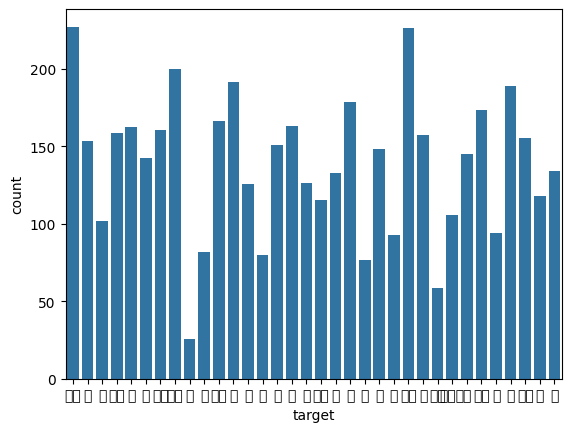

In [ ]:

# df.target.value_counts()
sns.countplot(x='target', data=df)


### Training

In [ ]:
X = np.array(df.iloc[:,:-1])
y = np.array(df['target'])

In [ ]:

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)


In [ ]:
!pip install imbalanced-learn      #for balancing training samples

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=0)
sm_X, sm_y = sm.fit_resample(X_train, y_train)  # Note: Use fit_resample instead of fit_sample


<Axes: xlabel='target', ylabel='count'>

/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2407 (\N{DEVANAGARI DIGIT ONE}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Matplotlib currently does not support Devanagari natively.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from current font.
  func(*args,

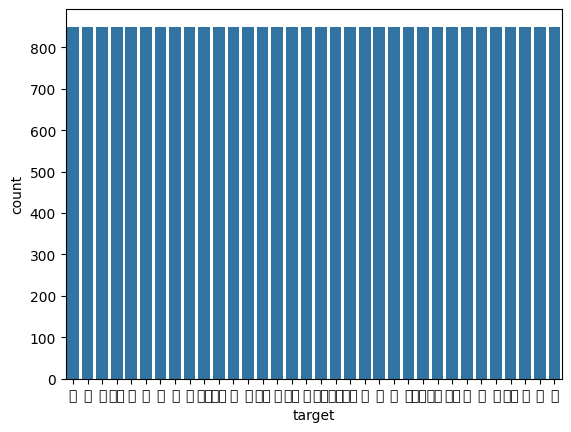

In [ ]:
bal_df = pd.DataFrame(sm_X, columns=[f'feature_{i}' for i in range(sm_X.shape[1])])  # Creating feature columns
bal_df['target'] = sm_y
sns.countplot(x="target",data = bal_df)


In [ ]:
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Implement PCA for dimensionality reduction
pca = PCA(n_components=1000)  # Adjust n_components based on your data

# Create an SVM model with HOG features and PCA
classifier = OneVsRestClassifier(
    svm.SVC(kernel='linear', probability=True),
    n_jobs=-1  # Enable parallel processing (use all cores)
)

# Create a pipeline with scaling, PCA, and classifier
model_pipeline = make_pipeline(StandardScaler(), pca, classifier)

# Train the model
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=1000)),
                ('onevsrestclassifier',
                 OneVsRestClassifier(estimator=SVC(kernel='linear',
                                                   probability=True),
                                     n_jobs=-1))])

### Accuracy on prediction

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9698568198944989
Classification Report:
               precision    recall  f1-score   support

           क       0.97      1.00      0.99       117
          को       1.00      1.00      1.00       150
           ख       0.98      0.97      0.97       127
           ग       0.94      0.99      0.96       138
           च       0.97      0.92      0.95       150
           ज       0.99      0.99      0.99       150
           झ       0.99      1.00      1.00       123
           ञ       1.00      0.98      0.99        83
          डि       1.00      1.00      1.00        96
           त       0.98      1.00      0.99       118
          ना       0.97      0.96      0.97       150
           प       0.93      0.94      0.93       150
         प्र       0.93      0.98      0.96        88
           ब       0.92      0.96      0.94        25
          बा       0.91      0.87      0.89       135
          भे       0.97      0.99      0.98       115
           म       0.99     

In [ ]:
import joblib
# Save the model to a file
joblib.dump(model_pipeline, 'svm_pca_pipeline_model.pkl')

print("Model saved successfully!")


Model saved successfully!


### Character Segmentaion

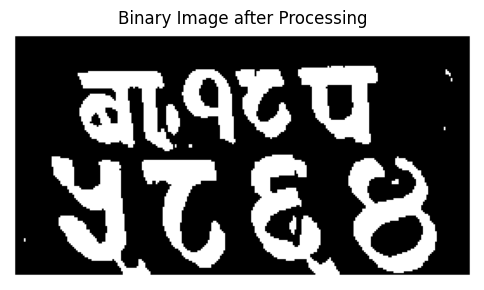

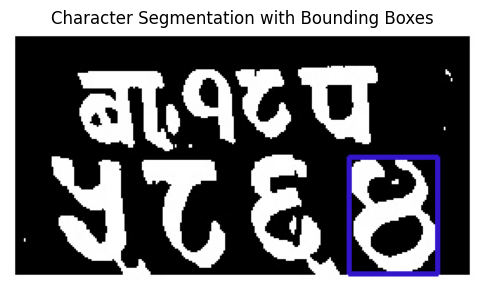

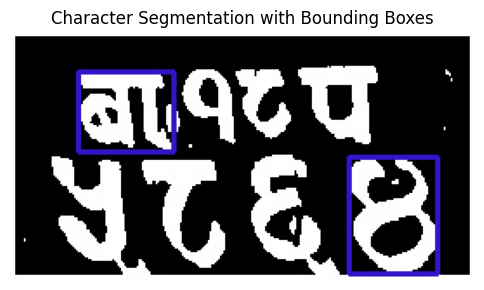

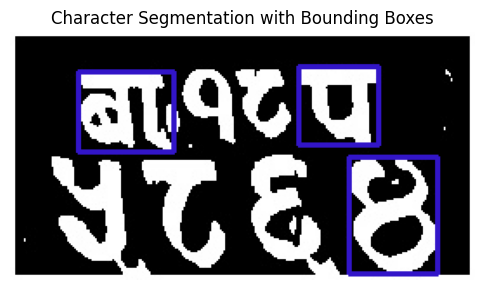

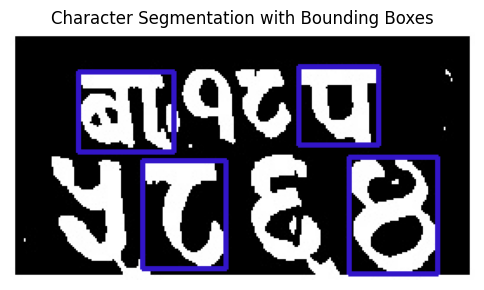

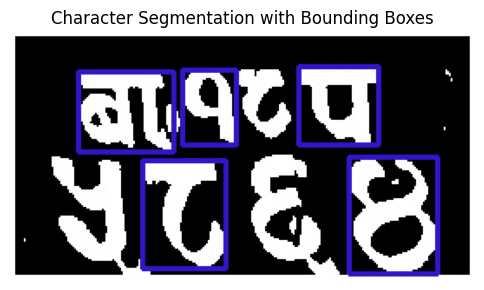

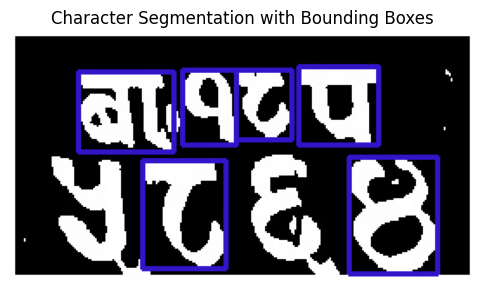

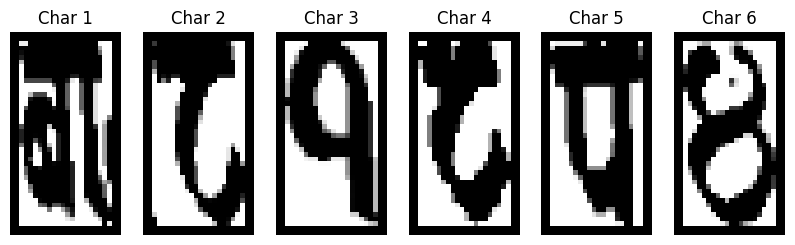

In [ ]:
import cv2                    
import numpy as np
import matplotlib.pyplot as plt

# Utility function to display the image
def show_image(image, title="Image"):
    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Preprocess the cropped license plate image for segmentation (without resizing)
async def segment_characters(image):
    # Step 1: Convert to grayscale (No resizing)
    img_gray_lp = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Step 2: Thresholding to convert the image to binary
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Step 3: Apply erosion and dilation to clean up the noise
    img_binary_lp = cv2.erode(img_binary_lp, (3, 3))
    img_binary_lp = cv2.dilate(img_binary_lp, (3, 3))

    # Make borders white to remove boundary noise
    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]
    img_binary_lp[0:3, :] = 255
    img_binary_lp[:, 0:3] = 255
    img_binary_lp[LP_WIDTH - 3:LP_WIDTH, :] = 255
    img_binary_lp[:, LP_HEIGHT - 3:LP_HEIGHT] = 255

    # Step 4: Define dimensions for contour filtering based on original image dimensions
    dimensions = [LP_WIDTH / 6, LP_WIDTH / 2, LP_HEIGHT / 10, 2 * LP_HEIGHT / 3]

    # Display the binary image
    show_image(img_binary_lp, title='Binary Image after Processing')

    # Save the processed image for contour detection visualization
    cv2.imwrite('contour.jpg', img_binary_lp)

    # Step 5: Find and return the character contours (pass the original binary image)
    char_list = await find_contours(dimensions, img_binary_lp)
    return char_list

# Find and filter the character contours based on size
async def find_contours(dimensions, img):
    # Step 1: Find contours
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Step 2: Retrieve potential dimensions
    lower_width, upper_width = dimensions[0], dimensions[1]
    lower_height, upper_height = dimensions[2], dimensions[3]

    # Step 3: Sort contours by size and consider the largest ones
    cntrs = sorted(cntrs, key=cv2.contourArea, reverse=True)[:15]

    # Load the image for visualization
    ii = cv2.imread('contour.jpg')

    x_cntr_list = []
    img_res = []

    # Step 4: Iterate through contours and filter by dimension
    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)

        if lower_width < intWidth < upper_width and lower_height < intHeight < upper_height:
            x_cntr_list.append(intX)

            char_copy = np.zeros((44, 24))
            char = img[intY:intY + intHeight, intX:intX + intWidth]
            char = cv2.resize(char, (20, 40))

            # Draw rectangle for visualization
            cv2.rectangle(ii, (intX, intY), (intX + intWidth, intY + intHeight), (50, 21, 200), 2)
            show_image(ii, title='Character Segmentation with Bounding Boxes')

            # Invert character colors and resize
            char = cv2.subtract(255, char)
            char_copy[2:42, 2:22] = char
            char_copy[0:2, :] = 0
            char_copy[:, 0:2] = 0
            char_copy[42:44, :] = 0
            char_copy[:, 22:24] = 0

            img_res.append(char_copy)

    # Step 5: Sort characters by their X-coordinate for correct order
    indices = sorted(range(len(x_cntr_list)), key=lambda k: x_cntr_list[k])
    img_res_sorted = [img_res[idx] for idx in indices]

    return np.array(img_res_sorted)

# Example usage for a license plate image
async def process_license_plate(image_path):
    # Read and preprocess the image (without resizing)
    license_plate_image = cv2.imread(image_path)
    if license_plate_image is None:
        print("Failed to load image.")
        return

    # Segment characters from the license plate
    characters = await segment_characters(license_plate_image)

    # Display each segmented character
    if characters.size > 0:
        plt.figure(figsize=(10, 6))
        for i, char_img in enumerate(characters):
            plt.subplot(1, len(characters), i + 1)
            plt.imshow(char_img, cmap='gray')
            plt.title(f'Char {i + 1}')
            plt.axis('off')
        plt.show()
    else:
        print("No characters found.")

# Example: Process license plate image (call async function)
image_path = '13.jpg'
await process_license_plate(image_path)


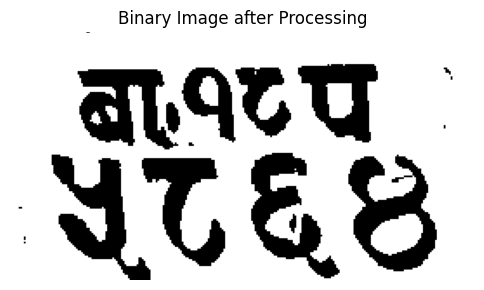

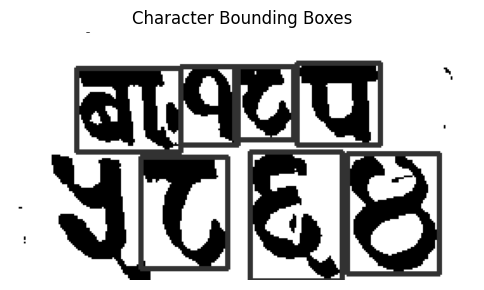

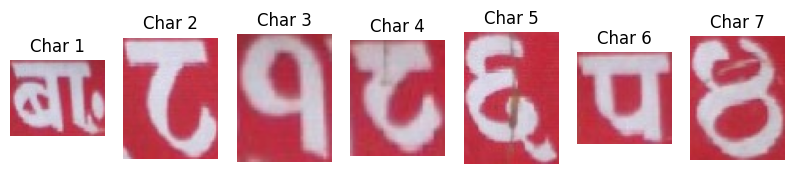

In [25]:
import cv2
import numpy as np               
import matplotlib.pyplot as plt

# Utility function to display the image
def show_image(image, title="Image"):
    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Preprocess the image and segment the characters
async def segment_characters(image):
    # Convert to grayscale
    img_gray_lp = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Threshold the image to binary
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert the binary image (white text on black background)
    img_binary_lp = cv2.bitwise_not(img_binary_lp)

    # Define dimensions for contour filtering based on original image dimensions
    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]
    dimensions = [LP_WIDTH / 6, LP_WIDTH / 2, LP_HEIGHT / 10, 2 * LP_HEIGHT / 3]

    # Display the binary image
    show_image(img_binary_lp, title='Binary Image after Processing')

    # Step 5: Find and return the character contours
    char_list = await find_contours(dimensions, img_binary_lp)
    return char_list

# Find and filter contours based on geometric properties (aspect ratio, area, etc.)
async def find_contours(dimensions, img):
    # Find contours
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Retrieve potential dimensions for filtering
    lower_width, upper_width = dimensions[0], dimensions[1]
    lower_height, upper_height = dimensions[2], dimensions[3]

    # Sort contours by X position for better row-wise segmentation
    cntrs = sorted(cntrs, key=lambda ctr: cv2.boundingRect(ctr)[0])

    # Load image for visualization
    img_copy = img.copy()

    char_list = []
    row_threshold = 30  # Adjust this threshold based on the image
    previous_y = 0
    current_row = []

    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)

        # Filter based on the aspect ratio and area
        aspect_ratio = intWidth / float(intHeight)
        area = intWidth * intHeight

        if lower_width < intWidth < upper_width and lower_height < intHeight < upper_height:
            if 0.2 < aspect_ratio < 1.5 and area > 100:  # Adjust these values based on image specifics
                # Group contours by their vertical position to handle rows
                if abs(intY - previous_y) > row_threshold and len(current_row) > 0:
                    char_list.append(current_row)
                    current_row = []

                current_row.append((intX, intY, intWidth, intHeight))
                previous_y = intY

                # Draw the bounding box
                cv2.rectangle(img_copy, (intX, intY), (intX + intWidth, intY + intHeight), (50, 21, 200), 2)

    # Append the last row
    if len(current_row) > 0:
        char_list.append(current_row)

    # Display the detected contours with bounding boxes
    show_image(img_copy, title='Character Bounding Boxes')

    # Flatten the list of rows and sort characters by X-axis within each row
    sorted_char_list = []
    for row in char_list:
        sorted_char_list += sorted(row, key=lambda x: x[0])

    return sorted_char_list

# Example usage for processing a license plate image
async def process_license_plate(image_path):
    # Read and preprocess the image
    license_plate_image = cv2.imread(image_path)
    if license_plate_image is None:
        print("Failed to load image.")
        return

    # Segment characters from the license plate
    characters = await segment_characters(license_plate_image)

    # Display each segmented character
    if characters:
        plt.figure(figsize=(10, 6))
        for i, (x, y, w, h) in enumerate(characters):
            char_img = license_plate_image[y:y+h, x:x+w]
            plt.subplot(1, len(characters), i + 1)
            plt.imshow(cv2.cvtColor(char_img, cv2.COLOR_BGR2RGB))  # Convert to RGB for correct color display
            plt.title(f'Char {i + 1}')
            plt.axis('off')
        plt.show()
    else:
        print("No characters found.")

# Example: Process the license plate image (call async function)
image_path = '13.jpg'
await process_license_plate(image_path)

# There is 40% chance that it maynot able to segment either one or two characters from numberplate and need to refine it,for now we will use this


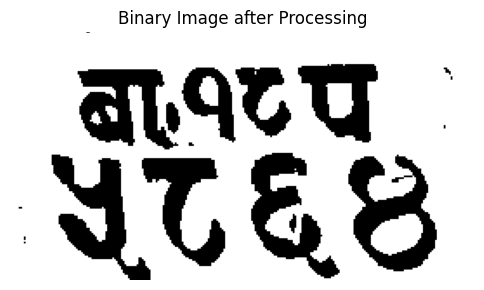

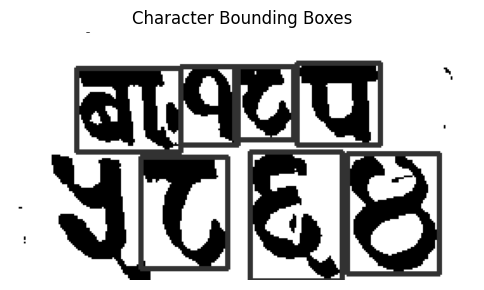

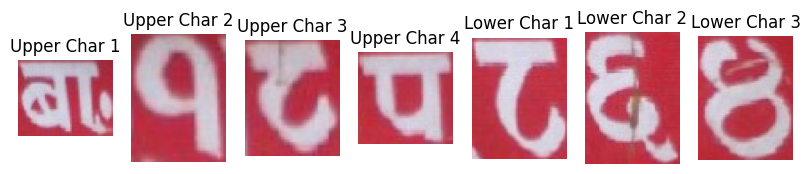

In [46]:
#here segmented characters are displayed in sequence.
import cv2 
import numpy as np
import matplotlib.pyplot as plt
import math

# Utility function to display the image
def show_image(image, title="Image"):
    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Calculate the distance between two points (x1, y1) and (x2, y2)
def calculate_distance(x1, y1, x2, y2):
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# Sort characters by their distance from the top-left corner of their row
def sort_by_distance(characters, row_left_top):
    # Calculate distances for each character bounding box within the row
    distances = [(i, calculate_distance(x + w // 2, y + h // 2, row_left_top[0], row_left_top[1]))
                 for i, (x, y, w, h) in enumerate(characters)]

    # Sort characters based on distance from the row's top-left corner
    distances.sort(key=lambda x: x[1])

    # Return sorted character list
    return [characters[i[0]] for i in distances]

# Assign characters to rows based on their center position relative to row bounds
def assign_characters_to_rows(characters, upper_row_coords, lower_row_coords):
    upper_row_left_top, upper_row_right_bottom = upper_row_coords
    lower_row_left_top, lower_row_right_bottom = lower_row_coords

    upper_row = []
    lower_row = []

    for char in characters:
        x, y, w, h = char
        center_x, center_y = x + w // 2, y + h // 2

        # Assign character to the upper row if its center falls within the upper row bounds
        if upper_row_left_top[0] <= center_x <= upper_row_right_bottom[0] and \
           upper_row_left_top[1] <= center_y <= upper_row_right_bottom[1]:
            upper_row.append(char)
        # Otherwise assign to the lower row if it falls within lower row bounds
        elif lower_row_left_top[0] <= center_x <= lower_row_right_bottom[0] and \
             lower_row_left_top[1] <= center_y <= lower_row_right_bottom[1]:
            lower_row.append(char)

    return upper_row, lower_row

# Preprocess the image and segment the characters
def segment_characters(image):
    # Convert to grayscale
    img_gray_lp = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Threshold the image to binary
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert the binary image (white text on black background)
    img_binary_lp = cv2.bitwise_not(img_binary_lp)

    # Define dimensions for contour filtering based on original image dimensions
    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]
    dimensions = [LP_WIDTH / 6, LP_WIDTH / 2, LP_HEIGHT / 10, 2 * LP_HEIGHT / 3]

    # Display the binary image
    show_image(img_binary_lp, title='Binary Image after Processing')

    # Step 5: Find and return the character contours
    char_list = find_contours(dimensions, img_binary_lp)
    return char_list, img_binary_lp.shape[0], img_binary_lp.shape[1]

# Find and filter contours based on geometric properties (aspect ratio, area, etc.)
def find_contours(dimensions, img):
    # Find contours
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Retrieve potential dimensions for filtering
    lower_width, upper_width = dimensions[0], dimensions[1]
    lower_height, upper_height = dimensions[2], dimensions[3]

    # Sort contours by X position for better row-wise segmentation
    cntrs = sorted(cntrs, key=lambda ctr: cv2.boundingRect(ctr)[0])

    # Load image for visualization
    img_copy = img.copy()

    char_list = []

    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)

        # Filter based on the aspect ratio and area
        aspect_ratio = intWidth / float(intHeight)
        area = intWidth * intHeight

        if lower_width < intWidth < upper_width and lower_height < intHeight < upper_height:
            if 0.2 < aspect_ratio < 1.5 and area > 100:  # Adjust these values based on image specifics
                char_list.append((intX, intY, intWidth, intHeight))
                # Draw the bounding box
                cv2.rectangle(img_copy, (intX, intY), (intX + intWidth, intY + intHeight), (50, 21, 200), 2)

    # Display the detected contours with bounding boxes
    show_image(img_copy, title='Character Bounding Boxes')

    return char_list

# Example usage for processing a license plate image
def process_license_plate(image_path):
    # Read and preprocess the image
    license_plate_image = cv2.imread(image_path)
    if license_plate_image is None:
        print("Failed to load image.")
        return

    # Segment characters from the license plate
    characters, plate_height, plate_width = segment_characters(license_plate_image)

    # Automatically split into two rows using the height of the license plate
    upper_row_left_top = (0, 0)  # Top-left of the upper row
    upper_row_right_bottom = (plate_width, plate_height // 2)  # Bottom-right of the upper row
    lower_row_left_top = (0, plate_height // 2)  # Top-left of the lower row
    lower_row_right_bottom = (plate_width, plate_height)  # Bottom-right of the lower row

    # Assign characters to rows based on their center position
    upper_row_characters, lower_row_characters = assign_characters_to_rows(
        characters, (upper_row_left_top, upper_row_right_bottom),
        (lower_row_left_top, lower_row_right_bottom))

    # Sort and display characters within the upper row
    sorted_upper_row = sort_by_distance(upper_row_characters, upper_row_left_top)

    # Sort and display characters within the lower row
    sorted_lower_row = sort_by_distance(lower_row_characters, lower_row_left_top)

    # Display upper row characters first, then lower row characters
    if sorted_upper_row or sorted_lower_row:
        plt.figure(figsize=(10, 6))

        # Display upper row characters
        for i, (x, y, w, h) in enumerate(sorted_upper_row):
            char_img = license_plate_image[y:y+h, x:x+w]
            plt.subplot(1, len(sorted_upper_row) + len(sorted_lower_row), i + 1)
            plt.imshow(cv2.cvtColor(char_img, cv2.COLOR_BGR2RGB))
            plt.title(f'Upper Char {i + 1}')
            plt.axis('off')

        # Display lower row characters
        for i, (x, y, w, h) in enumerate(sorted_lower_row):
            char_img = license_plate_image[y:y+h, x:x+w]
            plt.subplot(1, len(sorted_upper_row) + len(sorted_lower_row), len(sorted_upper_row) + i + 1)
            plt.imshow(cv2.cvtColor(char_img, cv2.COLOR_BGR2RGB))
            plt.title(f'Lower Char {i + 1}')
            plt.axis('off')

        plt.show()
    else:
        print("No characters found.")

# Example: Process the license plate image
image_path = '13.jpg'  #change with your path to image.
process_license_plate(image_path)


### Testing

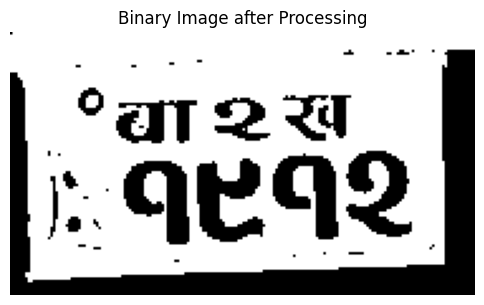

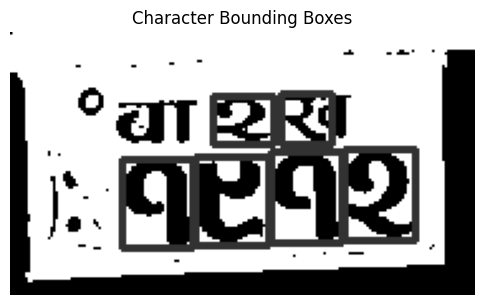

Recognized Characters (Upper Row): २सु
Recognized Characters (Lower Row): १९१२




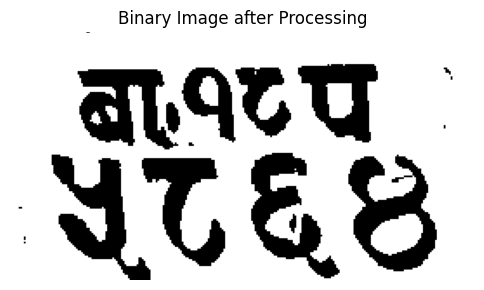

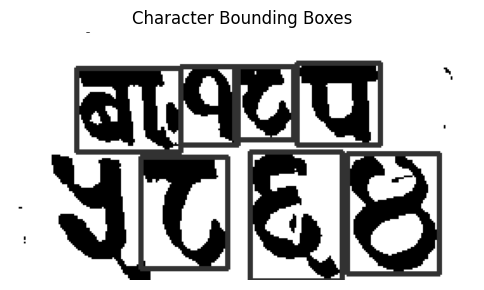

Recognized Characters (Upper Row): बा१७प
Recognized Characters (Lower Row): ८६४


In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import joblib  # For loading the trained SVM model

# Utility function to display the image
def show_image(image, title="Image"):
    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Calculate the distance between two points (x1, y1) and (x2, y2)
def calculate_distance(x1, y1, x2, y2):
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# Sort characters by their distance from the top-left corner of their row
def sort_by_distance(characters, row_left_top):
    distances = [(i, calculate_distance(x + w // 2, y + h // 2, row_left_top[0], row_left_top[1]))
                 for i, (x, y, w, h) in enumerate(characters)]
    distances.sort(key=lambda x: x[1])
    return [characters[i[0]] for i in distances]

# Assign characters to rows based on their center position relative to row bounds
def assign_characters_to_rows(characters, upper_row_coords, lower_row_coords):
    upper_row_left_top, upper_row_right_bottom = upper_row_coords
    lower_row_left_top, lower_row_right_bottom = lower_row_coords

    upper_row = []
    lower_row = []

    for char in characters:
        x, y, w, h = char
        center_x, center_y = x + w // 2, y + h // 2

        if upper_row_left_top[0] <= center_x <= upper_row_right_bottom[0] and \
           upper_row_left_top[1] <= center_y <= upper_row_right_bottom[1]:
            upper_row.append(char)
        elif lower_row_left_top[0] <= center_x <= lower_row_right_bottom[0] and \
             lower_row_left_top[1] <= center_y <= lower_row_right_bottom[1]:
            lower_row.append(char)

    return upper_row, lower_row

# Preprocess the image and segment the characters
def segment_characters(image):
    img_gray_lp = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, img_binary_lp = cv2.threshold(img_gray_lp, 200, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    img_binary_lp = cv2.bitwise_not(img_binary_lp)

    LP_WIDTH = img_binary_lp.shape[0]
    LP_HEIGHT = img_binary_lp.shape[1]
    dimensions = [LP_WIDTH / 6, LP_WIDTH / 2, LP_HEIGHT / 10, 2 * LP_HEIGHT / 3]

    show_image(img_binary_lp, title='Binary Image after Processing')
    char_list = find_contours(dimensions, img_binary_lp)
    return char_list, img_binary_lp.shape[0], img_binary_lp.shape[1]

# Find and filter contours based on geometric properties (aspect ratio, area, etc.)
def find_contours(dimensions, img):
    cntrs, _ = cv2.findContours(img.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    lower_width, upper_width = dimensions[0], dimensions[1]
    lower_height, upper_height = dimensions[2], dimensions[3]
    cntrs = sorted(cntrs, key=lambda ctr: cv2.boundingRect(ctr)[0])

    img_copy = img.copy()
    char_list = []

    for cntr in cntrs:
        intX, intY, intWidth, intHeight = cv2.boundingRect(cntr)
        aspect_ratio = intWidth / float(intHeight)
        area = intWidth * intHeight

        if lower_width < intWidth < upper_width and lower_height < intHeight < upper_height:
            if 0.2 < aspect_ratio < 1.5 and area > 100:
                char_list.append((intX, intY, intWidth, intHeight))
                cv2.rectangle(img_copy, (intX, intY), (intX + intWidth, intY + intHeight), (50, 21, 200), 2)

    show_image(img_copy, title='Character Bounding Boxes')
    return char_list

# Extract HOG features for each character
def extract_hog_features(character_image):
    img_resized = cv2.resize(character_image, (64, 128), interpolation=cv2.INTER_AREA)
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
    hog_features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(1, 1))
    return hog_features

# Function to classify the character using pre-trained SVM model
def classify_character(hog_features, svm_model):
    return svm_model.predict([hog_features])[0]  # The model expects a 2D array of features

# Load your trained SVM model
svm_model = joblib.load('svm_pca_pipeline_model.pkl')

# Classify each character after HOG extraction
def classify_characters(characters, original_image):
    predicted_labels = []
    for (x, y, w, h) in characters:
        char_img = original_image[y:y+h, x:x+w]
        hog_features = extract_hog_features(char_img)
        predicted_label = classify_character(hog_features, svm_model)
        predicted_labels.append(predicted_label)
    return predicted_labels

# Main function to process the license plate image and return classified characters
def process_license_plate(image_path):
    license_plate_image = cv2.imread(image_path)
    if license_plate_image is None:
        print("Failed to load image.")
        return

    # Segment characters from the license plate
    characters, plate_height, plate_width = segment_characters(license_plate_image)

    upper_row_left_top = (0, 0)
    upper_row_right_bottom = (plate_width, plate_height // 2)
    lower_row_left_top = (0, plate_height // 2)
    lower_row_right_bottom = (plate_width, plate_height)

    upper_row_characters, lower_row_characters = assign_characters_to_rows(
        characters, (upper_row_left_top, upper_row_right_bottom),
        (lower_row_left_top, lower_row_right_bottom))

    sorted_upper_row = sort_by_distance(upper_row_characters, upper_row_left_top)
    sorted_lower_row = sort_by_distance(lower_row_characters, lower_row_left_top)

    predicted_upper_row_labels = classify_characters(sorted_upper_row, license_plate_image)
    predicted_lower_row_labels = classify_characters(sorted_lower_row, license_plate_image)

    print("Recognized Characters (Upper Row):", ''.join(predicted_upper_row_labels))
    print("Recognized Characters (Lower Row):", ''.join(predicted_lower_row_labels))

# Example: Process the license plate image
image_path = '0001.jpg'  # Replace with the path to your test image
process_license_plate(image_path)
image_path2 = '13.jpg'
print("")
print("")
process_license_plate(image_path2) 
